## Momentum 


findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because none of the following families were found: KaiTi
findfont: Generic family 'sans-serif' not found because

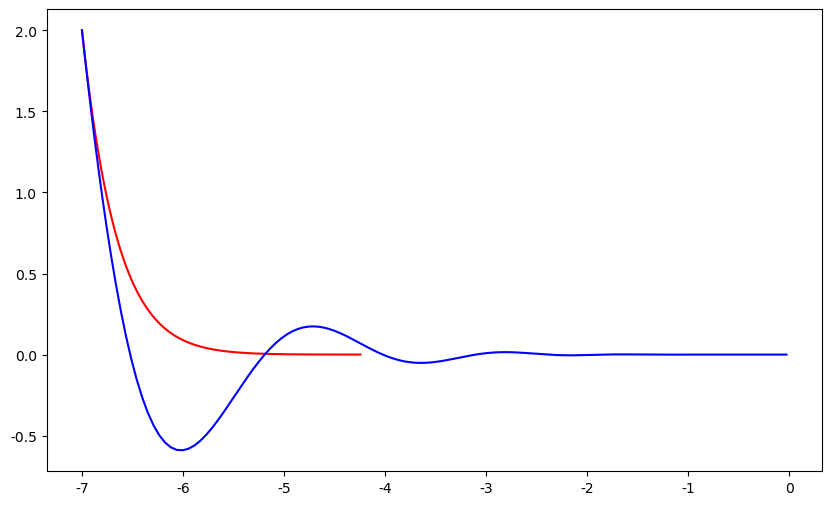

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch


# ==========================================
# 1. 定义梯度下降函数
# ==========================================
def gradient_descent(X, optimizer, n_iters):
  X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
  for epoch in range(n_iters):
    y = X ** 2 @ w
    y.backward()  # 反向传播
    optimizer.step()  # 更新参数
    optimizer.zero_grad()  # 清空梯度
    X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  return X_arr


# ==========================================
# 2. 初始化参数与超参数
# ==========================================
# 从(-7, 2)出发
X = torch.tensor([-7, 2], dtype=torch.float32, requires_grad=True)
w = torch.tensor([[0.05], [1.0]], requires_grad=True)
lr = 1e-2  # 学习率
n_iters = 500  # 迭代次数

# ==========================================
# 3. 运行优化算法
# ==========================================
plt.figure(figsize=(10, 6))

# (1) 普通梯度下降 (SGD)
X_clone1 = X.clone().detach().requires_grad_(True)
X_arr1 = gradient_descent(
  X_clone1, torch.optim.SGD([X_clone1], lr=lr), n_iters=n_iters
)
plt.plot(X_arr1[:, 0], X_arr1[:, 1], "r", label="SGD")

# (2) 动量法 (Momentum)
X_clone2 = X.clone().detach().requires_grad_(True)
X_arr2 = gradient_descent(
  X_clone2, torch.optim.SGD([X_clone2], lr=lr, momentum=0.9), n_iters=n_iters
)
plt.plot(X_arr2[:, 0], X_arr2[:, 1], "b", label="Momentum")

# ==========================================
# 4. 绘制等高线并显示图表
# ==========================================
x1_grid, x2_grid = np.meshgrid(np.linspace(-7, 7, 100), np.linspace(-2, 2, 100))
y_grid = w.detach().numpy()[0, 0]

## 学习率衰减


### 常见的衰减策略对比

根据不同的场景，你可以选择不同的衰减方式：

| 调度器名称 | 衰减方式 | 适用场景 |
| :--- | :--- | :--- |
| **`StepLR`** | 每隔固定步数（Step）衰减一次 | 训练轮数较长、规律性强的标准网络训练 |
| **`MultiStepLR`** | 在指定的特定轮次（Milestones）衰减 | 手动控制衰减节点（例如：在第50轮、第150轮时衰减） |
| **`ExponentialLR`** | 按指数函数平滑衰减 | 希望学习率随着训练平滑、持续缩小的场景 |

### 等间隔衰减

tensor([-7.,  2.], requires_grad=True)


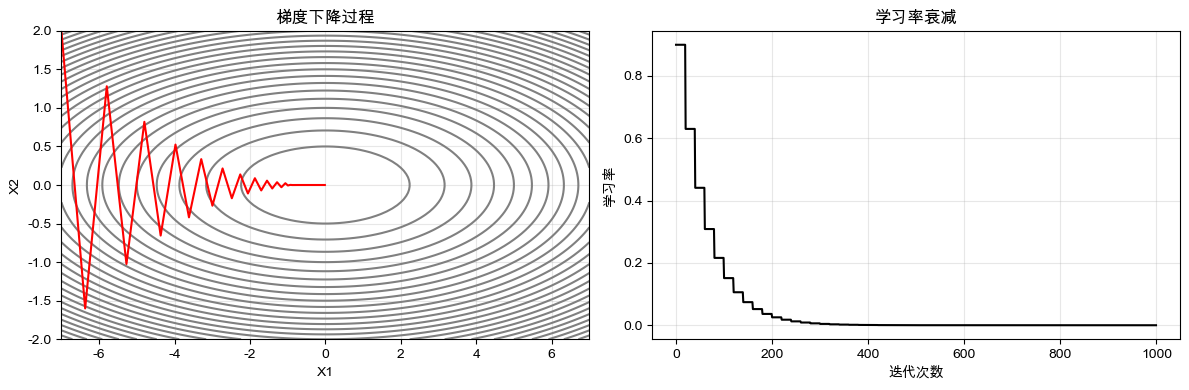

In [7]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 初始化参数与超参数
# ==========================================
# 从(-7, 2)出发
X = torch.tensor([-7, 2], dtype=torch.float32, requires_grad=True)
print(X)
w = torch.tensor([[0.05], [1.0]], requires_grad=True)
lr = 0.9  # 初始学习率
n_iters = 1000  # 迭代次数

# ==========================================
# 2. 定义优化器与学习率调度器
# ==========================================
optimizer = torch.optim.SGD([X], lr=lr)
# 学习率衰减
scheduler_lr = torch.optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.7)

# 记录变量
X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
lr_list = []  # 记录学习率变化

# ==========================================
# 3. 梯度下降循环
# ==========================================
for epoch in range(n_iters):
  y = X ** 2 @ w
  y.backward()  # 反向传播
  optimizer.step()  # 更新参数
  optimizer.zero_grad()  # 清空梯度

  X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  lr_list.append(optimizer.param_groups[0]["lr"])  # 记录学习率变化
  scheduler_lr.step()  # 学习率衰减

# ==========================================
# 4. 绘制可视化结果
# ==========================================
# 1. 设置 macOS 支持的中文字体
# 'Arial Unicode MS' 或 'PingFang SC' (苹方) 在 Mac 上通常最管用
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

# 2. 解决更换字体后，坐标轴上的负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 左侧图：等高线与梯度下降轨迹
x1_grid, x2_grid = np.meshgrid(np.linspace(-7, 7, 100), np.linspace(-2, 2, 100))
y_grid = w.detach().numpy()[0, 0] * x1_grid ** 2 + w.detach().numpy()[1, 0] * x2_grid ** 2

ax[0].contour(x1_grid, x2_grid, y_grid, levels=30, colors="gray")
ax[0].plot(X_arr[:, 0], X_arr[:, 1], "r")
ax[0].set_title("梯度下降过程")
ax[0].set_xlabel("X1")
ax[0].set_ylabel("X2")
ax[0].grid(True, alpha=0.3)

# 右侧图：学习率变化曲线
ax[1].plot(lr_list, "k")
ax[1].set_title("学习率衰减")
ax[1].set_xlabel("迭代次数")
ax[1].set_ylabel("学习率")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 指定间隔衰减

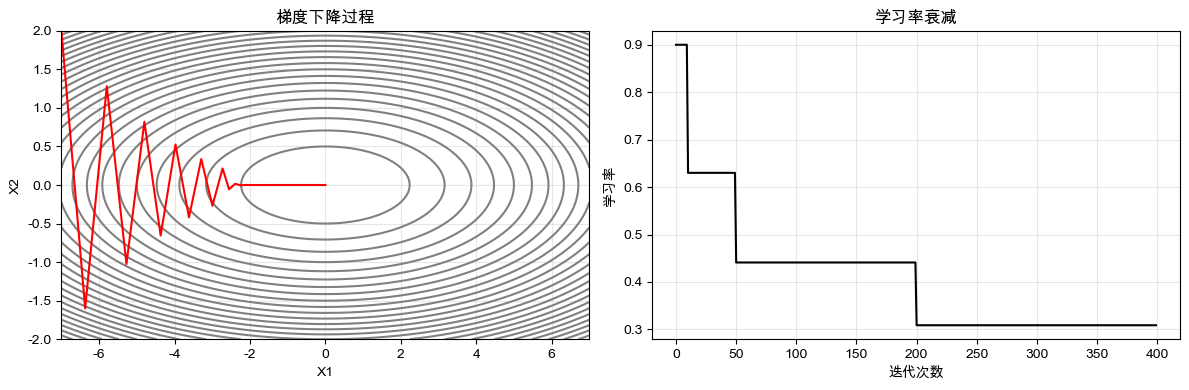

In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 初始化参数与超参数
# ==========================================
# 从(-7, 2)出发
X = torch.tensor([-7, 2], dtype=torch.float32, requires_grad=True)
w = torch.tensor([[0.05], [1.0]], requires_grad=True)
lr = 0.9  # 初始学习率
n_iters = 400  # 迭代次数

# ==========================================
# 2. 定义优化器与学习率调度器
# ==========================================
optimizer = torch.optim.SGD([X], lr=lr)
# 学习率衰减（使用 MultiStepLR，在 milestones 指定的 epoch 处衰减）
scheduler_lr = torch.optim.lr_scheduler.MultiStepLR(
  optimizer, milestones=[10, 50, 200], gamma=0.7
)

# 记录变量
X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
lr_list = []  # 记录学习率变化

# ==========================================
# 3. 梯度下降循环
# ==========================================
for epoch in range(n_iters):
  y = X ** 2 @ w
  y.backward()  # 反向传播
  optimizer.step()  # 更新参数
  optimizer.zero_grad()  # 清空梯度

  X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  lr_list.append(optimizer.param_groups[0]["lr"])  # 记录学习率变化
  scheduler_lr.step()  # 学习率衰减

# ==========================================
# 4. 绘制可视化结果
# ==========================================
# 1. 设置 macOS 支持的中文字体
# 'Arial Unicode MS' 或 'PingFang SC' (苹方) 在 Mac 上通常最管用
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

# 2. 解决更换字体后，坐标轴上的负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 左侧图：等高线与梯度下降轨迹
x1_grid, x2_grid = np.meshgrid(np.linspace(-7, 7, 100), np.linspace(-2, 2, 100))
y_grid = w.detach().numpy()[0, 0] * x1_grid ** 2 + w.detach().numpy()[1, 0] * x2_grid ** 2

ax[0].contour(x1_grid, x2_grid, y_grid, levels=30, colors="gray")
ax[0].plot(X_arr[:, 0], X_arr[:, 1], "r")
ax[0].set_title("梯度下降过程")
ax[0].set_xlabel("X1")
ax[0].set_ylabel("X2")
ax[0].grid(True, alpha=0.3)

# 右侧图：学习率变化曲线
ax[1].plot(lr_list, "k")
ax[1].set_title("学习率衰减")
ax[1].set_xlabel("迭代次数")
ax[1].set_ylabel("学习率")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 指数衰减

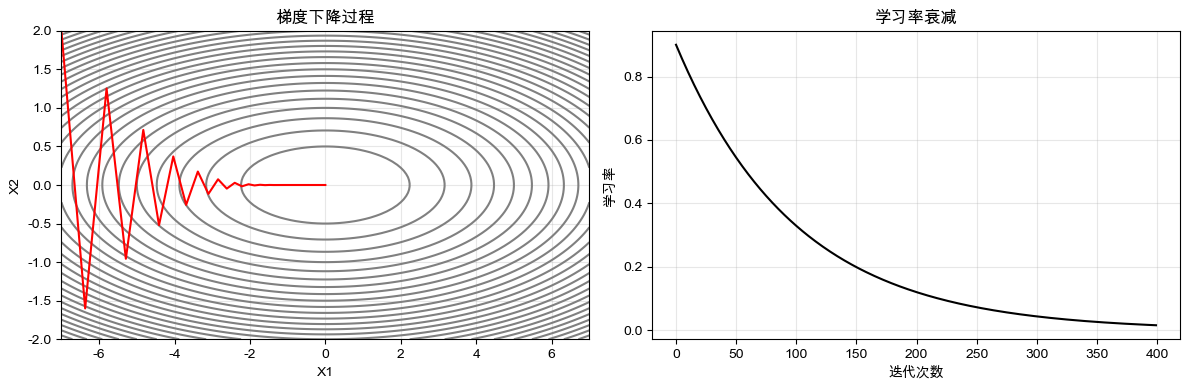

In [11]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. 初始化参数与超参数
# ==========================================
# 从(-7, 2)出发
X = torch.tensor([-7, 2], dtype=torch.float32, requires_grad=True)
w = torch.tensor([[0.05], [1.0]], requires_grad=True)
lr = 0.9  # 初始学习率
n_iters = 400  # 迭代次数

# ==========================================
# 2. 定义优化器与学习率调度器
# ==========================================
optimizer = torch.optim.SGD([X], lr=lr)
# 学习率指数衰减
scheduler_lr = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.99)

# 记录变量
X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
lr_list = []  # 记录学习率变化

# ==========================================
# 3. 梯度下降循环
# ==========================================
for epoch in range(n_iters):
  y = X ** 2 @ w
  y.backward()  # 反向传播
  optimizer.step()  # 更新参数
  optimizer.zero_grad()  # 清空梯度

  X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  lr_list.append(optimizer.param_groups[0]["lr"])  # 记录学习率变化
  scheduler_lr.step()  # 学习率衰减

# ==========================================
# 4. 绘制可视化结果
# ==========================================
# 1. 设置 macOS 支持的中文字体
# 'Arial Unicode MS' 或 'PingFang SC' (苹方) 在 Mac 上通常最管用
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']

# 2. 解决更换字体后，坐标轴上的负号 '-' 显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# 左侧图：等高线与梯度下降轨迹
x1_grid, x2_grid = np.meshgrid(np.linspace(-7, 7, 100), np.linspace(-2, 2, 100))
y_grid = w.detach().numpy()[0, 0] * x1_grid ** 2 + w.detach().numpy()[1, 0] * x2_grid ** 2

ax[0].contour(x1_grid, x2_grid, y_grid, levels=30, colors="gray")
ax[0].plot(X_arr[:, 0], X_arr[:, 1], "r")
ax[0].set_title("梯度下降过程")
ax[0].set_xlabel("X1")
ax[0].set_ylabel("X2")
ax[0].grid(True, alpha=0.3)

# 右侧图：学习率变化曲线
ax[1].plot(lr_list, "k")
ax[1].set_title("学习率衰减")
ax[1].set_xlabel("迭代次数")
ax[1].set_ylabel("学习率")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## AdaGrad

AdaGrad（Adaptive Gradient，自适应梯度）会为每个参数适当地调整学习率，并且随着学习的进行，梯度会逐渐减小。

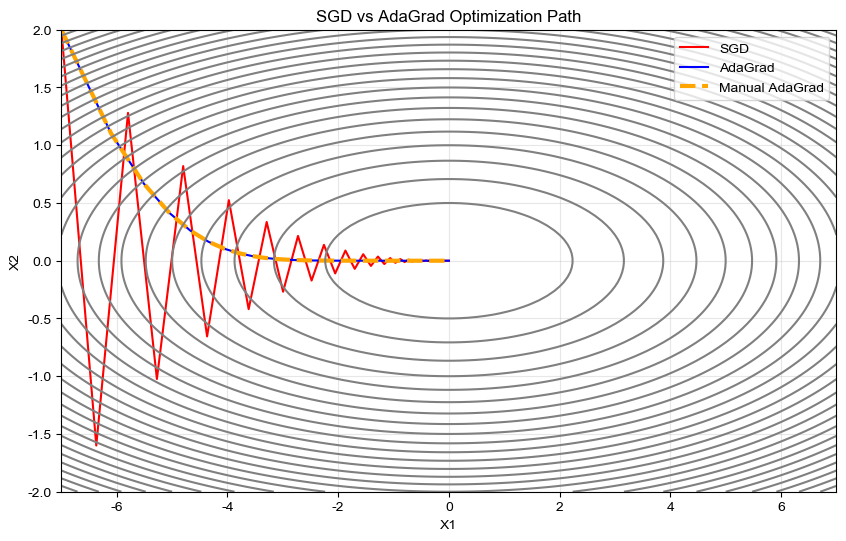

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. 定义优化器函数
# ==========================================
def adagrad(X, lr, n_iters):
  """AdaGrad手动实现"""
  X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
  H = torch.zeros_like(X)  # 存放历史梯度信息
  for epoch in range(n_iters):
    grad = 2 * X * w.T  # 当前梯度
    grad.squeeze_()  # 降维
    H += grad ** 2  # 平方和
    X.data -= lr / (torch.sqrt(H) + 1e-8) * grad  # 更新参数，这里H后面加1e-8防止分母为0
    X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  return X_arr


def gradient_descent(X, optimizer, n_iters):
  X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
  for epoch in range(n_iters):
    y = X ** 2 @ w
    y.backward()  # 反向传播
    optimizer.step()  # 更新参数
    optimizer.zero_grad()  # 清空梯度
    X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  return X_arr


# ==========================================
# 2. 初始化参数与超参数
# ==========================================
# 从(-7, 2)出发
X = torch.tensor([-7, 2], dtype=torch.float32, requires_grad=True)
w = torch.tensor([[0.05], [1.0]], requires_grad=True)
lr = 0.9  # 学习率
n_iters = 500  # 迭代次数

plt.figure(figsize=(10, 6))

# ==========================================
# 3. 运行优化算法并记录轨迹
# ==========================================
# (1) 普通梯度下降 (SGD)
X_clone1 = X.clone().detach().requires_grad_(True)
X_arr1 = gradient_descent(
  X_clone1, torch.optim.SGD([X_clone1], lr=lr), n_iters=n_iters
)
plt.plot(X_arr1[:, 0], X_arr1[:, 1], "r", label="SGD")

# (2) AdaGrad (使用 PyTorch 内置)
X_clone2 = X.clone().detach().requires_grad_(True)
X_arr2 = gradient_descent(
  X_clone2, torch.optim.Adagrad([X_clone2], lr=lr), n_iters=n_iters
)
plt.plot(X_arr2[:, 0], X_arr2[:, 1], "b", label="AdaGrad")

# (3) AdaGrad (手动实现)
X_clone3 = X.clone().detach().requires_grad_(True)
X_arr3 = adagrad(X_clone3, lr=lr, n_iters=n_iters)
plt.plot(
  X_arr3[:, 0],
  X_arr3[:, 1],
  color="orange",
  linestyle="--",
  linewidth=3,
  label="Manual AdaGrad"
)

# ==========================================
# 4. 绘制等高线并显示图表
# ==========================================
x1_grid, x2_grid = np.meshgrid(np.linspace(-7, 7, 100), np.linspace(-2, 2, 100))
y_grid = w.detach().numpy()[0, 0] * x1_grid ** 2 + w.detach().numpy()[1, 0] * x2_grid ** 2

plt.contour(x1_grid, x2_grid, y_grid, levels=30, colors="gray")
plt.title("SGD vs AdaGrad Optimization Path")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### RMSProp

RMSProp（Root Mean Square Propagation，均方根传播）是在AdaGrad基础上的改进，它并非将过去所有梯度一视同仁的相加，而是逐渐遗忘过去的梯度，采用指数移动加权平均，呈指数地减小过去梯度的尺度。

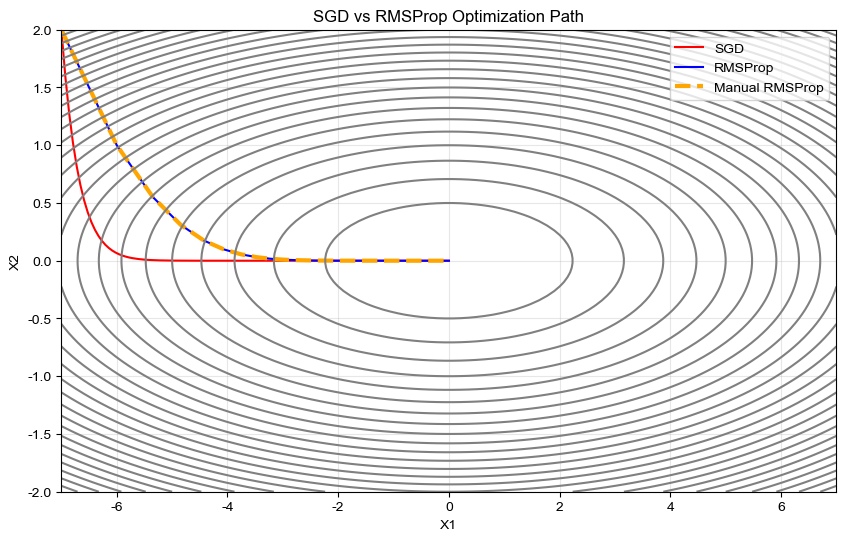

In [14]:
import torch
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. 定义优化器函数
# ==========================================
def rmspropp(X, lr, alpha, n_iters):
  """RMSProp手动实现"""
  X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
  H = torch.zeros_like(X)  # 存放历史梯度信息
  for epoch in range(n_iters):
    grad = 2 * X * w.T  # 当前梯度
    grad.squeeze_()  # 降维
    H = alpha * H + (1 - alpha) * grad ** 2  # 历史梯度平方和的指数加权平均
    X.data -= lr / (torch.sqrt(H) + 1e-8) * grad  # 更新参数，这里H后面加1e-8防止分母为0
    X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  return X_arr


def gradient_descent(X, optimizer, n_iters):
  X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
  for epoch in range(n_iters):
    y = X ** 2 @ w
    y.backward()  # 反向传播
    optimizer.step()  # 更新参数
    optimizer.zero_grad()  # 清空梯度
    X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  return X_arr


# ==========================================
# 2. 初始化参数与超参数
# ==========================================
# 从(-7, 2)出发
X = torch.tensor([-7, 2], dtype=torch.float32, requires_grad=True)
w = torch.tensor([[0.05], [1.0]], requires_grad=True)
lr = 1e-1  # 学习率
n_iters = 1000  # 迭代次数

plt.figure(figsize=(10, 6))

# ==========================================
# 3. 运行优化算法并记录轨迹
# ==========================================
# (1) 普通梯度下降 (SGD)
X_clone1 = X.clone().detach().requires_grad_(True)
X_arr1 = gradient_descent(
  X_clone1, torch.optim.SGD([X_clone1], lr=lr), n_iters=n_iters
)
plt.plot(X_arr1[:, 0], X_arr1[:, 1], "r", label="SGD")

# (2) RMSProp (使用 PyTorch 内置)
X_clone2 = X.clone().detach().requires_grad_(True)
X_arr2 = gradient_descent(
  X_clone2, torch.optim.RMSprop([X_clone2], lr=lr, alpha=0.99), n_iters=n_iters
)
plt.plot(X_arr2[:, 0], X_arr2[:, 1], "b", label="RMSProp")

# (3) RMSProp (手动实现)
X_clone3 = X.clone().detach().requires_grad_(True)
X_arr3 = rmspropp(X_clone3, lr=lr, alpha=0.99, n_iters=n_iters)
plt.plot(
  X_arr3[:, 0],
  X_arr3[:, 1],
  color="orange",
  linestyle="--",
  linewidth=3,
  label="Manual RMSProp"
)

# ==========================================
# 4. 绘制等高线并显示图表
# ==========================================
x1_grid, x2_grid = np.meshgrid(np.linspace(-7, 7, 100), np.linspace(-2, 2, 100))
y_grid = w.detach().numpy()[0, 0] * x1_grid ** 2 + w.detach().numpy()[1, 0] * x2_grid ** 2

plt.contour(x1_grid, x2_grid, y_grid, levels=30, colors="gray")
plt.title("SGD vs RMSProp Optimization Path")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Adam

Adam（Adaptive Moment Estimation，自适应矩估计）融合了Momentum和AdaGrad的方法。

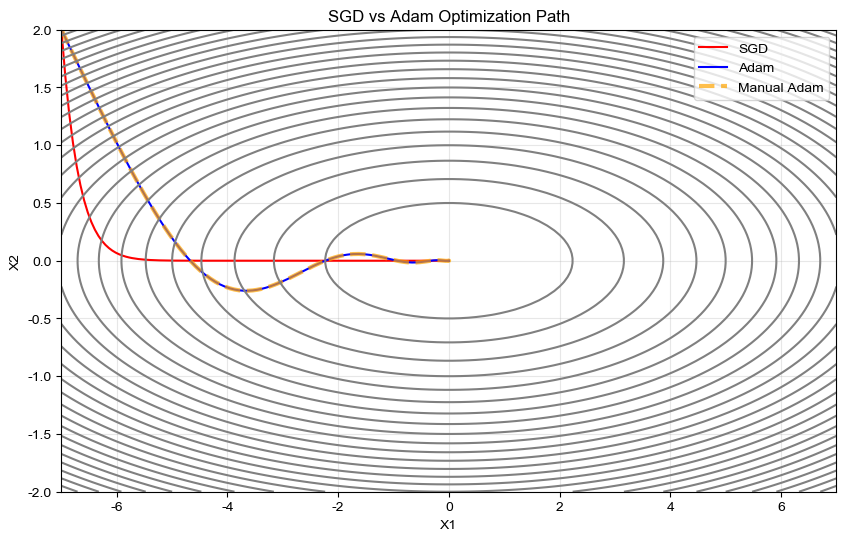

In [15]:
import torch
import numpy as np
import matplotlib.pyplot as plt


# ==========================================
# 1. 定义优化器函数
# ==========================================
def adam(X, lr, betas, n_iters):
  """Adam手动实现"""
  X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
  V = torch.zeros_like(X)  # 存放历史梯度信息
  H = torch.zeros_like(X)  # 存放历史梯度信息

  for epoch in range(n_iters):
    grad = 2 * X * w.T  # 当前梯度
    grad.squeeze_()  # 降维

    V = betas[0] * V + (1 - betas[0]) * grad  # 历史梯度的指数加权平均
    H = betas[1] * H + (1 - betas[1]) * grad ** 2  # 历史梯度平方和的指数加权平均

    V_hat = V / (1 - betas[0] ** (epoch + 1))
    H_hat = H / (1 - betas[1] ** (epoch + 1))

    X.data -= lr * V_hat / (torch.sqrt(H_hat) + 1e-8)  # 更新参数，这里H后面加1e-8防止分母为0

    X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  return X_arr


def gradient_descent(X, optimizer, n_iters):
  X_arr = X.detach().numpy().copy()  # 拷贝，用于记录优化过程
  for epoch in range(n_iters):
    y = X ** 2 @ w
    y.backward()  # 反向传播
    optimizer.step()  # 更新参数
    optimizer.zero_grad()  # 清空梯度

    X_arr = np.vstack([X_arr, X.detach().numpy()])  # 记录优化过程
  return X_arr


# ==========================================
# 2. 初始化参数与超参数
# ==========================================
# 从(-7, 2)出发
X = torch.tensor([-7, 2], dtype=torch.float32, requires_grad=True)
w = torch.tensor([[0.05], [1.0]], requires_grad=True)
lr = 1e-1  # 学习率
n_iters = 1000  # 迭代次数

plt.figure(figsize=(10, 6))

# ==========================================
# 3. 运行优化算法并记录轨迹
# ==========================================
# (1) 普通梯度下降 (SGD)
X_clone1 = X.clone().detach().requires_grad_(True)
X_arr1 = gradient_descent(
  X_clone1, torch.optim.SGD([X_clone1], lr=lr), n_iters=n_iters
)
plt.plot(X_arr1[:, 0], X_arr1[:, 1], "r", label="SGD")

# (2) Adam (使用 PyTorch 内置)
X_clone2 = X.clone().detach().requires_grad_(True)
X_arr2 = gradient_descent(
  X_clone2, torch.optim.Adam([X_clone2], lr=lr, betas=(0.9, 0.999)), n_iters=n_iters
)
plt.plot(X_arr2[:, 0], X_arr2[:, 1], "b", label="Adam")

# (3) Adam (手动实现)
X_clone3 = X.clone().detach().requires_grad_(True)
X_arr3 = adam(X_clone3, lr=lr, betas=(0.9, 0.999), n_iters=n_iters)
plt.plot(
  X_arr3[:, 0],
  X_arr3[:, 1],
  color="orange",
  linestyle="--",
  linewidth=3,
  alpha=0.7,
  label="Manual Adam"
)

# ==========================================
# 4. 绘制等高线并显示图表
# ==========================================
x1_grid, x2_grid = np.meshgrid(np.linspace(-7, 7, 100), np.linspace(-2, 2, 100))
y_grid = w.detach().numpy()[0, 0] * x1_grid ** 2 + w.detach().numpy()[1, 0] * x2_grid ** 2

plt.contour(x1_grid, x2_grid, y_grid, levels=30, colors="gray")
plt.title("SGD vs Adam Optimization Path")
plt.xlabel("X1")
plt.ylabel("X2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()